# Compare L2 error across runs

Loads `l2_error.csv` from each output directory and plots mean relative position error vs timestep.

First run `./run_post_processing.sh` for each case to get `l2_error.csv`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Output dirs from run_post_processing.sh (lines 5-10)
notebook_dir = Path(".").resolve()
repo_root = notebook_dir.parents[3]  # physicsnemo
outputs_dir = repo_root / "outputs"

run_names = {
    "Transolver(Adam)": "input directory name",
    "Transolver(Muon)": "input directory name",
    "GeoTransolver(Adam)": "input directory name",
    "GeoTransolver(Muon)": "input directory name",
    "GeoFlare(Adam)": "input directory name",
    "GeoFlare(Muon)": "input directory name",
}

data = {}
for name, dir_name in run_names.items():
    csv_path = outputs_dir / dir_name / "post_processing_results" / "l2_error.csv"
    if csv_path.exists():
        data[name] = pd.read_csv(csv_path)
    else:
        print(f"Skipping (not found): {csv_path}")

print(f"Loaded {len(data)} runs.")

Loaded 6 runs.


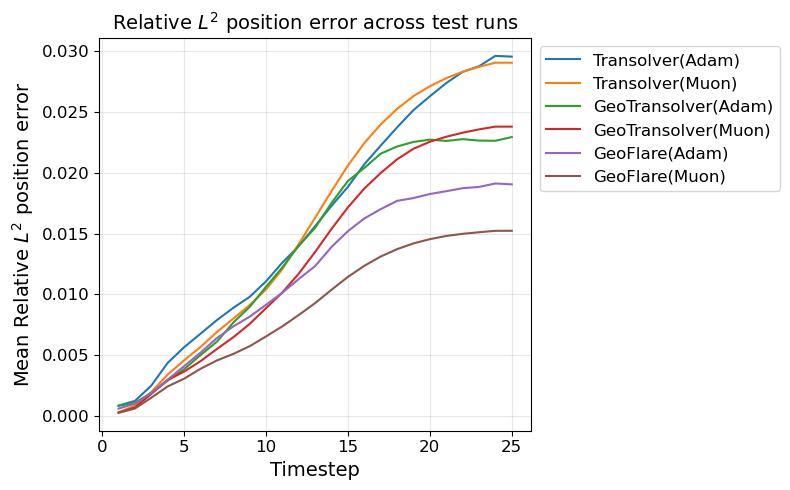

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, df in data.items():
    t = df["timestep"]
    mean_err = df["mean_relative_position_error"]
    std_err = df["std_relative_position_error"]
    label = name.replace("car_oneshot_direct_", "").replace("_", " ")
    ax.plot(t, mean_err, label=label)
    # ax.fill_between(t, mean_err - std_err, mean_err + std_err, alpha=0.2)

ax.set_xlabel("Timestep", fontsize=14)
ax.set_ylabel("Mean Relative $L^2$ position error", fontsize=14)
ax.set_title("Relative $L^2$ position error across test runs", fontsize=14)
ax.legend(bbox_to_anchor=(1.0, 1), loc="upper left", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [12]:
for name, df in data.items():
    print(name, data[name]["mean_relative_position_error"].mean())

Transolver(Adam) 0.01595723960914511
Transolver(Muon) 0.01602681240066882
GeoTransolver(Adam) 0.014015633360083563
GeoTransolver(Muon) 0.013274615449232125
GeoFlare(Adam) 0.01163968610593912
GeoFlare(Muon) 0.008948673980859323
